# Employee Database Deduplication

### Submitted By: Mobeen Maroof
### Registration No: Mtech-DS26013

## Objective
The purpose of this project is to clean an employee database by removing duplicate records, fixing inconsistent names, handling missing values, and preparing a clean dataset for analysis.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [31]:
df = pd.read_csv("employee_data.csv")

In [32]:
df.head(10)

,EmployeeID,Name,Department,Salary,Email
0,101,Ali Khan,HR,50000,ali@gmail.com
1,102,Sara Ahmed,IT,70000,sara@gmail.com
2,103,Ahmed Ali,Finance,65000,ahmed@gmail.com
3,104,Fatima Noor,HR,52000,fatima@gmail.com
4,105,fatima noor,HR,52000,fatima@gmail.com
5,106,Bilal Hassan,Marketing,48000,bilal@gmail.com
6,107,Ayesha Malik,IT,75000,ayesha@gmail.com
7,108,Hamza Sheikh,Finance,68000,hamza@gmail.com
8,109,Usman Raza,Sales,45000,usman@gmail.com
9,110,Zara Noor,HR,55000,zara@gmail.com


In [33]:
print("Rows and Columns:", df.shape)

Rows and Columns: (36, 5)


In [34]:
df.columns

Index(['EmployeeID', 'Name', 'Department', 'Salary', 'Email'], dtype='object')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   EmployeeID  36 non-null     int64 
 1   Name        36 non-null     object
 2   Department  36 non-null     object
 3   Salary      36 non-null     int64 
 4   Email       36 non-null     object
dtypes: int64(2), object(3)
memory usage: 1.5+ KB


In [36]:
df.describe()

,EmployeeID,Salary
count,36.000000,36.000000
mean,118.500000,58277.777778
std,10.535654,11030.765059
min,101.000000,44000.000000
25%,109.750000,49750.000000
50%,118.500000,54250.000000
75%,127.250000,68250.000000
max,136.000000,81000.000000


In [37]:
df.isnull().sum()

EmployeeID    0
Name          0
Department    0
Salary        0
Email         0
dtype: int64

In [38]:
duplicates = df[df.duplicated()]
duplicates

,EmployeeID,Name,Department,Salary,Email


In [39]:
duplicates = df[df.duplicated(subset=["Name", "Email"], keep=False)]
duplicates

,EmployeeID,Name,Department,Salary,Email
0,101,Ali Khan,HR,50000,ali@gmail.com
1,102,Sara Ahmed,IT,70000,sara@gmail.com
5,106,Bilal Hassan,Marketing,48000,bilal@gmail.com
10,111,Ali Khan,HR,50000,ali@gmail.com
30,131,Sara Ahmed,IT,70000,sara@gmail.com
32,133,Bilal Hassan,Marketing,48000,bilal@gmail.com


In [40]:
df["Name"] = df["Name"].str.strip()

In [41]:
df["Name"] = df["Name"].str.title()

In [42]:
df.head()

,EmployeeID,Name,Department,Salary,Email
0,101,Ali Khan,HR,50000,ali@gmail.com
1,102,Sara Ahmed,IT,70000,sara@gmail.com
2,103,Ahmed Ali,Finance,65000,ahmed@gmail.com
3,104,Fatima Noor,HR,52000,fatima@gmail.com
4,105,Fatima Noor,HR,52000,fatima@gmail.com


In [43]:
df = df.drop_duplicates()

In [44]:
print(df.shape)

(36, 5)


In [45]:
print(df.duplicated().sum())

0


In [46]:
department = df["Department"].value_counts()

department

Department
HR           12
IT            8
Finance       7
Sales         5
Marketing     4
Name: count, dtype: int64

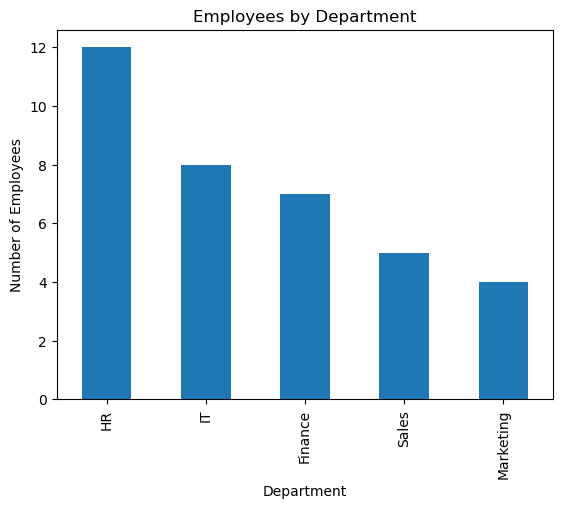

In [47]:
department.plot(kind="bar")

plt.title("Employees by Department")

plt.xlabel("Department")

plt.ylabel("Number of Employees")

plt.show()

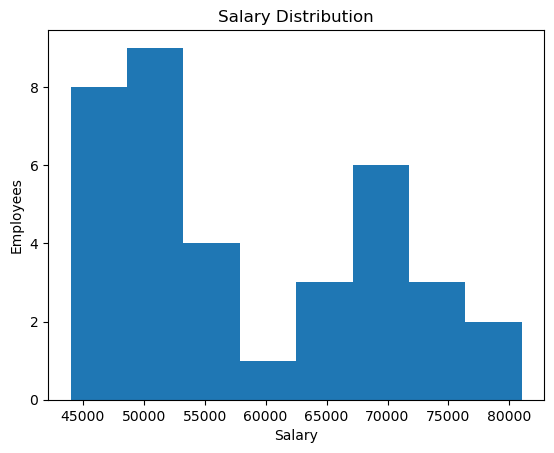

In [48]:
plt.hist(df["Salary"], bins=8)

plt.title("Salary Distribution")

plt.xlabel("Salary")

plt.ylabel("Employees")

plt.show()

In [49]:
print("Average Salary =", df["Salary"].mean())

Average Salary = 58277.77777777778


In [50]:
print("Highest Salary =", df["Salary"].max())

Highest Salary = 81000


In [51]:
print("Lowest Salary =", df["Salary"].min())

Lowest Salary = 44000


In [52]:
df[df["Department"]=="IT"]

,EmployeeID,Name,Department,Salary,Email
1,102,Sara Ahmed,IT,70000,sara@gmail.com
6,107,Ayesha Malik,IT,75000,ayesha@gmail.com
11,112,Hina Akram,IT,72000,hina@gmail.com
16,117,Danish Ali,IT,81000,danish@gmail.com
21,122,Sana Tariq,IT,70500,sana@gmail.com
26,127,Huzaifa Khan,IT,78000,huzaifa@gmail.com
30,131,Sara Ahmed,IT,70000,sara@gmail.com
33,134,Zain Abbas,IT,76000,zain@gmail.com


In [53]:
df[df["Department"]=="HR"]

,EmployeeID,Name,Department,Salary,Email
0,101,Ali Khan,HR,50000,ali@gmail.com
3,104,Fatima Noor,HR,52000,fatima@gmail.com
4,105,Fatima Noor,HR,52000,fatima@gmail.com
9,110,Zara Noor,HR,55000,zara@gmail.com
10,111,Ali Khan,HR,50000,ali@gmail.com
15,116,Mariam Iqbal,HR,53000,mariam@gmail.com
19,120,Iqra Ahmed,HR,56000,iqra@gmail.com
20,121,Ali Khan,HR,50000,ali@gmail.com
25,126,Mahnoor Ali,HR,54000,mahnoor@gmail.com
29,130,Aiman Khan,HR,51500,aiman@gmail.com


In [54]:
df[df["Department"]=="Finance"]

,EmployeeID,Name,Department,Salary,Email
2,103,Ahmed Ali,Finance,65000,ahmed@gmail.com
7,108,Hamza Sheikh,Finance,68000,hamza@gmail.com
12,113,Omar Farooq,Finance,61000,omar@gmail.com
17,118,Areeba Khan,Finance,69000,areeba@gmail.com
22,123,Kamran Shah,Finance,63000,kamran@gmail.com
27,128,Laiba Iqbal,Finance,67500,laiba@gmail.com
31,132,Ahmed Ali,Finance,65000,ahmed@gmail.com


In [58]:
df.to_csv("clean_employee_data.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.
